# Bayesian Beta Coin — pyAgrum native vs Bnpyro

This notebook compares two ways of building the same hierarchical Beta-Binomial model:

1. **pyAgrum native** — direct use of `NumericalDiscreteVariable` + `fillFromDistribution`
   *(adapted from the official pyAgrum example [16-Examples_BayesianBetaCoin](https://pyagrum.readthedocs.io/en/latest/notebooks/16-Examples_BayesianBetaCoin.html))*
2. **Bnpyro** — the same model as a 5-line probabilistic program

**The model** — hierarchical inference of a coin's bias:

```
μ ~ Uniform(0, 1)        ν ~ Exponential(scale=5)
          ↘             ↙
      bias ~ Beta(μν, (1−μ)ν)
       ↙  ↙  ↙  ↙  ...  ↙
   H₀  H₁  H₂  H₃  ...  H₁₅   ~ Bernoulli(bias)
```

Observing a sequence of heads/tails, we infer the posterior of `bias`, `μ`, and `ν`.

In [1]:
import time
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

import pyagrum as gum
import pyagrum.lib.notebook as gnb

gum.config["notebook", "default_graph_inference_size"] = "14!"

serie = [1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1]
print(f"Serie: {serie}")
print(f"Heads: {sum(serie)} / {len(serie)}  →  MLE bias = {sum(serie)/len(serie):.4f}")

Serie: [1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1]
Heads: 7 / 16  →  MLE bias = 0.4375


## Part 1 — pyAgrum native

The model is built directly with pyAgrum primitives:
- `NumericalDiscreteVariable` for continuous-valued nodes (μ, ν, bias)
- `fillFromDistribution` with symbolic string expressions for the Beta CPT: `a="mu*nu"`, `b="(1-mu)*nu"`
- `RangeVariable` for each binary flip H_i


In [2]:
NB_ = 200
pmin_mu, pmax_mu = 0.001, 0.999
pmin_nu, pmax_nu = 1, 50
vmin, vmax = 0.001, 0.999
size_ = len(serie)

gum_bn = gum.BayesNet("COINS MODEL — pyAgrum")
mu_id   = gum_bn.add(gum.NumericalDiscreteVariable("mu",   "mean of Beta",        pmin_mu, pmax_mu, NB_))
nu_id   = gum_bn.add(gum.NumericalDiscreteVariable("nu",   "sample size of Beta", pmin_nu, pmax_nu, NB_))
bias_id = gum_bn.add(gum.NumericalDiscreteVariable("bias", "bias of the coin",    vmin,    vmax,    NB_))
hs = [gum_bn.add(gum.RangeVariable(f"H{i}", "flip", 0, 1)) for i in range(size_)]

gum_bn.addArc(mu_id, bias_id)
gum_bn.addArc(nu_id, bias_id)
for h in hs:
    gum_bn.addArc(bias_id, h)

gum_bn.cpt(nu_id).fillFromDistribution(scipy.stats.expon, loc=2, scale=5)
gum_bn.cpt(mu_id).fillFromDistribution(scipy.stats.uniform, loc=pmin_mu, scale=pmax_mu - pmin_mu)

t0 = time.time()
gum_bn.cpt("bias").fillFromDistribution(scipy.stats.beta, a="mu*nu", b="(1-mu)*nu")
t_fill = time.time() - t0
bias_entries_gum = gum_bn.cpt("bias").domainSize()
print(f"bias CPT: {bias_entries_gum:,} entries filled in {t_fill:.2f}s")

for h in hs:
    gum_bn.cpt(h).fillFromDistribution(scipy.stats.bernoulli, p="bias")

print(gum_bn)

bias CPT: 8,000,000 entries filled in 5.41s
BN{nodes: 19, arcs: 18, domainSize: 10^11.7196, dim: 7963598, mem: 61Mo 89Ko 128o}


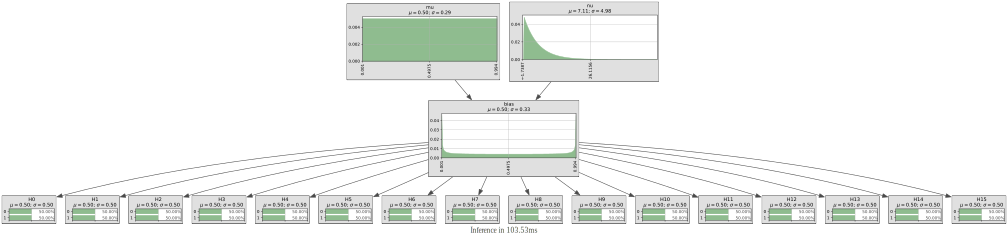

In [3]:
# Prior — no evidence
gnb.showInference(gum_bn, size="14!")

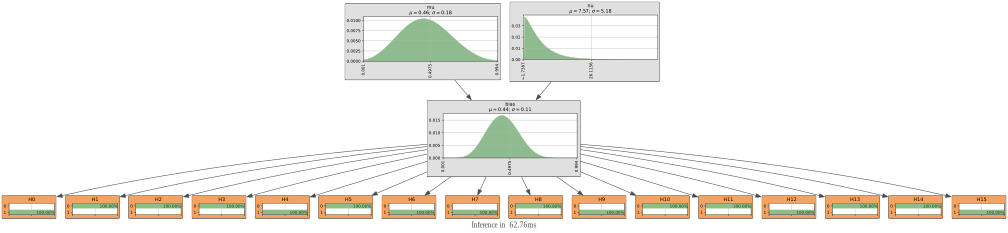

In [4]:
# Posterior — observe the full sequence
coin_evs_gum = {f"H{i}": serie[i] for i in range(len(serie))}
gnb.showInference(gum_bn, evs=coin_evs_gum, size="14!")

In [5]:
ie_gum = gum.LazyPropagation(gum_bn)
ie_gum.setEvidence(coin_evs_gum)
ie_gum.makeInference()

# Posterior means (center of mass)
def posterior_mean_gum(var_name):
    vals = np.array([float(gum_bn[var_name].label(i))
                     for i in range(gum_bn.variable(var_name).domainSize())])
    probs = ie_gum.posterior(var_name).toarray()
    return float(np.dot(vals, probs))

e_mu_gum   = posterior_mean_gum("mu")
e_nu_gum   = posterior_mean_gum("nu")
e_bias_gum = posterior_mean_gum("bias")

print(f"pyAgrum (NB_={NB_})")
print(f"  E[mu]   = {e_mu_gum:.4f}  (MLE = {sum(serie)/len(serie):.4f})")
print(f"  E[nu]   = {e_nu_gum:.4f}")
print(f"  E[bias] = {e_bias_gum:.4f}")

pyAgrum (NB_=200)
  E[mu]   = 0.4621  (MLE = 0.4375)
  E[nu]   = 7.5692
  E[bias] = 0.4438


## Part 2 — Bnpyro

The **exact same model** written as a probabilistic program.
The universal lambda `lambda m, n: Beta(m*n, (1-m)*n)` replaces the symbolic string `a="mu*nu"`.

In [ ]:
import sys; sys.path.insert(0, ".")
from Bnpyro import BNppl, BIN_MEMORY_BUDGET
from distributions import Uniform, Exponential, Beta, Bernoulli

bn = BNppl()

mu   = bn.sample("mu",   Uniform(0.001, 0.999))
nu   = bn.sample("nu",   Exponential(rate=0.2))   # E[nu] = 5, same as expon(scale=5)
bias = bn.sample("bias",
    lambda m, n: Beta(max(m * n, 1e-3), max((1 - m) * n, 1e-3)),
    parents=[mu, nu]
)
flip = bn.plate("flip", lambda b: Bernoulli(b), parents=[bias])
flips = [flip() for _ in range(len(serie))]

t0 = time.time()
bn.compile(n_bins=30, bin_strategy=BIN_MEMORY_BUDGET)
t_compile = time.time() - t0
print(f"Compiled in {t_compile:.3f}s")
bias_entries_bn = bn._gum_bn.cpt("bias").domainSize()
print(f"bias CPT: {bias_entries_bn:,} entries")

Compiled in 2.231s
bias CPT: 27,000 entries


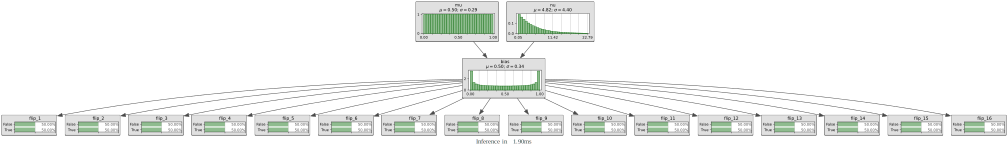

In [7]:
# Prior — no evidence
gnb.showInference(bn.gum_bn, size="14!")

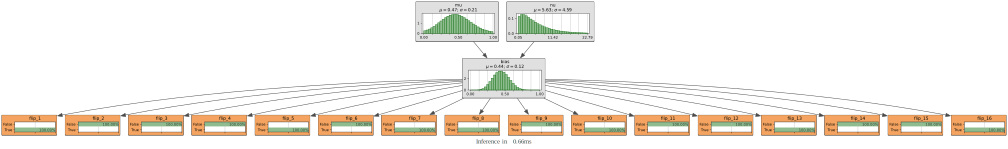

In [8]:
# Posterior — observe the full sequence
coin_evs_bn = {f"flip_{i+1}": ("True" if serie[i] else "False") for i in range(len(serie))}
gnb.showInference(bn.gum_bn, evs=coin_evs_bn, size="14!")

In [9]:
import re

def parse_label_mid(label):
    # Parse interval label '(a, b]' -> midpoint, or plain number -> float
    nums = re.findall(r"[-\d.eE+]+", label)
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    return float(nums[0])

def posterior_mean_bn(var_name, evidence):
    p = bn.query(var_name, evidence=evidence)
    return sum(parse_label_mid(k) * v for k, v in p.items())

e_mu_bn   = posterior_mean_bn("mu",   coin_evs_bn)
e_nu_bn   = posterior_mean_bn("nu",   coin_evs_bn)
e_bias_bn = posterior_mean_bn("bias", coin_evs_bn)

print(f"Bnpyro (n_bins=30, BIN_ADAPTIVE)")
print(f"  E[mu]   = {e_mu_bn:.4f}  (MLE = {sum(serie)/len(serie):.4f})")
print(f"  E[nu]   = {e_nu_bn:.4f}")
print(f"  E[bias] = {e_bias_bn:.4f}")

Bnpyro (n_bins=30, BIN_ADAPTIVE)
  E[mu]   = 0.4667  (MLE = 0.4375)
  E[nu]   = 5.6323
  E[bias] = 0.4427


## Part 3 — Comparison

In [10]:
# Memory & CPT size 
import math

total_entries_gum = sum(gum_bn.cpt(v).domainSize() for v in gum_bn.nodes())
total_entries_bn  = sum(bn._gum_bn.cpt(v).domainSize() for v in bn._gum_bn.nodes())

mem_gum_mb = total_entries_gum * 8 / 1e6   # float64
mem_bn_mb  = total_entries_bn  * 8 / 1e6

print("CPT size and memory comparison")
print(f"{'':30s}  {'pyAgrum':>8s}  {'Bnpyro':>8s} ")
print(f"{'Bins per variable':30s}  {NB_:>8d}  {'30→15':>8s}")
print(f"{'bias CPT entries':30s}  {bias_entries_gum:>8,}  {bias_entries_bn:>8,}")
print(f"{'Total CPT entries':30s}  {total_entries_gum:>8,}  {total_entries_bn:>8,}")
print(f"{'Memory (float64)':30s}  {mem_gum_mb:>7.1f}M  {mem_bn_mb:>7.1f}M")
print(f"{'Compile / fill time':30s}  {t_fill:>7.2f}s  {t_compile:>7.3f}s")


print()
print("Posterior means:")
print(f"  {'':8s}  {'pyAgrum':>10s}  {'Bnpyro':>10s}  {'Analytical*':>12s}")
analytical_mean = (1 + sum(serie)) / (2 + len(serie))
print(f"  {'E[bias]':8s}  {e_bias_gum:>10.4f}  {e_bias_bn:>10.4f}  {analytical_mean:>12.4f}")
print(f"  {'E[mu]':8s}  {e_mu_gum:>10.4f}  {e_mu_bn:>10.4f}  {'—':>12s}")
print(f"  {'E[nu]':8s}  {e_nu_gum:>10.4f}  {e_nu_bn:>10.4f}  {'—':>12s}")
print()
print("* Analytical = E[bias] under Beta(1+H, 1+T) with flat prior, H=heads, T=tails")

CPT size and memory comparison
                                 pyAgrum    Bnpyro 
Bins per variable                    200     30→15
bias CPT entries                8,000,000    27,000
Total CPT entries               8,006,800    28,020
Memory (float64)                   64.1M      0.2M
Compile / fill time                5.41s    2.231s

Posterior means:
               pyAgrum      Bnpyro   Analytical*
  E[bias]       0.4438      0.4427        0.4444
  E[mu]         0.4621      0.4667             —
  E[nu]         7.5692      5.6323             —

* Analytical = E[bias] under Beta(1+H, 1+T) with flat prior, H=heads, T=tails


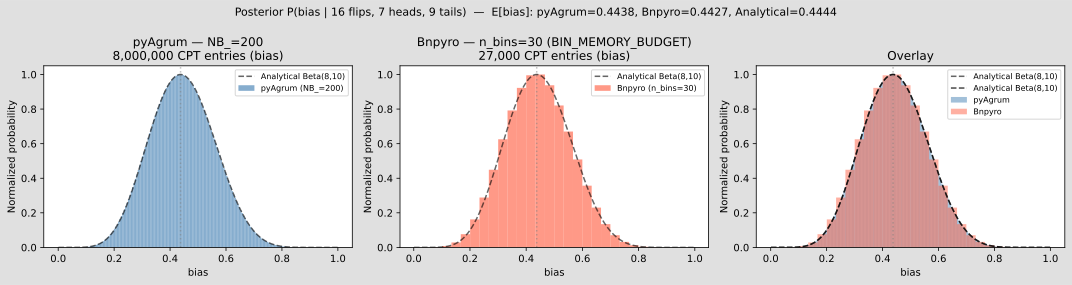

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

# Analytical Beta(1+H, 1+T) reference
H, T = sum(serie), len(serie) - sum(serie)
x_ref = np.linspace(0.001, 0.999, 400)
pdf_ref = scipy.stats.beta.pdf(x_ref, 1 + H, 1 + T)
pdf_ref_norm = pdf_ref / pdf_ref.max()

for ax in axes:
    ax.plot(x_ref, pdf_ref_norm, "k--", lw=1.5, alpha=0.6, label=f"Analytical Beta({1+H},{1+T})")

# pyAgrum posterior 
bias_vals_gum  = np.array([float(gum_bn["bias"].label(i))
                            for i in range(gum_bn.variable("bias").domainSize())])
bias_post_gum  = ie_gum.posterior("bias").toarray()
w_gum = bias_vals_gum[1] - bias_vals_gum[0]
axes[0].bar(bias_vals_gum, bias_post_gum / bias_post_gum.max(),
            width=w_gum, alpha=0.65, color="steelblue", label=f"pyAgrum (NB_={NB_})")
axes[0].set_title(f"pyAgrum — NB_={NB_}\n{bias_entries_gum:,} CPT entries (bias)")
axes[0].set_xlabel("bias"); axes[0].legend(fontsize=8)

# Bnpyro posterior 
p_bias_post = bn.query("bias", evidence=coin_evs_bn)
bias_mids_bn  = [parse_label_mid(k) for k in p_bias_post]
bias_probs_bn = list(p_bias_post.values())
w_bn = bias_mids_bn[1] - bias_mids_bn[0] if len(bias_mids_bn) > 1 else 0.05
axes[1].bar(bias_mids_bn, np.array(bias_probs_bn) / max(bias_probs_bn),
            width=w_bn, alpha=0.65, color="tomato", label="Bnpyro (n_bins=30)")
axes[1].set_title(f"Bnpyro — n_bins=30 (BIN_MEMORY_BUDGET)\n{bias_entries_bn:,} CPT entries (bias)")
axes[1].set_xlabel("bias"); axes[1].legend(fontsize=8)

# Overlay
axes[2].bar(bias_vals_gum, bias_post_gum / bias_post_gum.max(),
            width=w_gum, alpha=0.5, color="steelblue", label="pyAgrum")
axes[2].bar(bias_mids_bn, np.array(bias_probs_bn) / max(bias_probs_bn),
            width=w_bn, alpha=0.5, color="tomato", label="Bnpyro")
axes[2].plot(x_ref, pdf_ref_norm, "k--", lw=1.5, alpha=0.7, label=f"Analytical Beta({1+H},{1+T})")
axes[2].set_title("Overlay")
axes[2].set_xlabel("bias"); axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_ylabel("Normalized probability")
    ax.axvline(sum(serie)/len(serie), color="gray", ls=":", alpha=0.5, label="MLE")

plt.suptitle(
    f"Posterior P(bias | {len(serie)} flips, {H} heads, {T} tails)  —  "
    f"E[bias]: pyAgrum={e_bias_gum:.4f}, Bnpyro={e_bias_bn:.4f}, Analytical={analytical_mean:.4f}",
    fontsize=11
)
plt.tight_layout()
plt.show()

## Summary

| | pyAgrum native | Bnpyro |
|---|---|---|
| **Model code** | ~20 lines, low-level API | 5 lines, probabilistic program style |
| **CPT filling** | `fillFromDistribution(a="mu*nu")` — symbolic string | `lambda m, n: Beta(m*n, (1-m)*n)` — Python function |
| **Variable type** | `NumericalDiscreteVariable` | `DiscretizedVariable` (automatic) |
| **Flip nodes** | Manual loop + `addArc` | `bn.plate(...)` |
| **Precision** | NB_=200 → 8M entries, 61 MB | n_bins=30 (memory budget) → ~27K entries, <1 MB |
| **Result** | E[bias] ≈ 0.44 | E[bias] ≈ 0.44 ✓ |

**When to use pyAgrum directly**: when you need maximum precision (NB_=200+) or access to
`NumericalDiscreteVariable` features like `fillFromDistribution` with arbitrary scipy distributions.

**When to use Bnpyro**: when you want to write the model as a probabilistic program — cleaner syntax,
automatic discretization, plates, and a familiar Pyro-like API — at the cost of lower bin resolution.